# Advanced Analytics: VaR, Cohort Analysis & Fund Recommender

This notebook performs three advanced analytical tasks on the Mutual Fund dataset:
1. **Value at Risk (VaR) Deep Dive** – parametric, historical, and conditional VaR with backtesting
2. **Cohort Analysis** – quarterly investor retention cohorts
3. **Fund Recommender Walkthrough** – profile-based fund scoring and recommendation

> **Dependencies:** pandas, numpy, scipy, matplotlib, seaborn, plotly (optional for interactivity)


In [1]:
# ==================== Imports ====================
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Use plotly for interactive charts where possible
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed; using matplotlib for all charts.")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("All imports successful.")


All imports successful.


---
# Section 1: Value at Risk (VaR) Deep Dive

**Objective:** Compute multiple VaR metrics (Parametric, Historical, CVaR) for each fund and backtest their accuracy.

**Key Insight:** Historical VaR is more conservative than parametric for funds with non-normal return distributions.


In [2]:
# ==================== 1. Load Data ====================
nav = pd.read_csv('../data/processed/02_nav_history.csv', parse_dates=['date'])
fund_master = pd.read_csv('../data/processed/01_fund_master.csv')

print(f"NAV records: {len(nav):,}")
print(f"Funds: {len(fund_master)}")
print(f"Date range: {nav['date'].min()} to {nav['date'].max()}")
nav.head(5)


NAV records: 46,000
Funds: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
# ==================== 2. Compute Daily Returns ====================
nav_sorted = nav.sort_values(['amfi_code', 'date']).copy()
nav_sorted['daily_return'] = nav_sorted.groupby('amfi_code')['nav'].transform('pct_change')

# Drop NaN from first obs per fund
returns = nav_sorted.dropna(subset=['daily_return']).copy()

print(f"Return observations: {len(returns):,}")
returns.head(5)


Return observations: 45,960


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [4]:
# ==================== 3. VaR Calculation Functions ====================
def parametric_var(returns, alpha=0.05):
    mu = returns.mean()
    sigma = returns.std()
    z = stats.norm.ppf(alpha)
    return mu + z * sigma

def historical_var(returns, alpha=0.05):
    return np.percentile(returns, alpha * 100)

def cvar(returns, alpha=0.05):
    threshold = historical_var(returns, alpha)
    tail = returns[returns <= threshold]
    return tail.mean() if len(tail) > 0 else threshold

# ==================== 4. Compute VaR for each fund ====================
grouped = returns.groupby('amfi_code')['daily_return']

var_results = []
for amfi, grp in grouped:
    vals = grp.values
    var_results.append({
        'amfi_code': amfi,
        'VaR_95_param': parametric_var(vals, 0.05),
        'VaR_95_hist':  historical_var(vals, 0.05),
        'CVaR_95':      cvar(vals, 0.05),
        'VaR_99_param': parametric_var(vals, 0.01),
        'VaR_99_hist':  historical_var(vals, 0.01),
        'CVaR_99':      cvar(vals, 0.01),
    })

var_df = pd.DataFrame(var_results)
var_df = var_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Round for readability
for col in ['VaR_95_param', 'VaR_95_hist', 'CVaR_95', 'VaR_99_param', 'VaR_99_hist', 'CVaR_99']:
    var_df[col] = var_df[col].round(6)

print(f"VaR computed for {len(var_df)} funds")
var_df.head(10)


VaR computed for 40 funds


,amfi_code,VaR_95_param,VaR_95_hist,CVaR_95,VaR_99_param,VaR_99_hist,CVaR_99,scheme_name
0,100016,-0.014926,-0.014364,-0.018060,-0.021169,-0.020392,-0.022138,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003875,-0.003793,-0.004994,-0.005550,-0.005832,-0.006963,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.018533,-0.019034,-0.023456,-0.026659,-0.025443,-0.030326,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.014237,-0.013282,-0.017439,-0.020488,-0.019648,-0.024748,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026294,-0.026021,-0.032459,-0.037364,-0.037071,-0.042086,ABSL Small Cap Fund - Regular - Growth
5,101208,-0.000283,-0.000269,-0.000422,-0.000500,-0.000527,-0.000620,ABSL Liquid Fund - Regular - Growth
6,102885,-0.012621,-0.012613,-0.015490,-0.018129,-0.017732,-0.019205,UTI Nifty 50 Index Fund - Regular - Growth
7,102886,-0.018672,-0.019220,-0.023251,-0.026454,-0.025472,-0.029030,UTI Mid Cap Fund - Regular - Growth
8,102887,-0.015676,-0.015232,-0.019411,-0.022438,-0.022572,-0.024905,UTI Flexi Cap Fund - Regular - Growth
9,118632,-0.013788,-0.013954,-0.017619,-0.019860,-0.019392,-0.022569,Nippon India Large Cap Fund - Regular - Growth


In [5]:
# ==================== 5. Comparison Table ====================
comparison = var_df[['amfi_code', 'scheme_name',
                      'VaR_95_param', 'VaR_95_hist', 'CVaR_95',
                      'VaR_99_param', 'VaR_99_hist', 'CVaR_99']].copy()
comparison.columns = ['fund_code', 'scheme_name',
                       'VaR_95_param', 'VaR_95_hist', 'CVaR_95',
                       'VaR_99_param', 'VaR_99_hist', 'CVaR_99']

# Show all rows (no truncation)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    display(comparison)


,fund_code,scheme_name,VaR_95_param,VaR_95_hist,CVaR_95,VaR_99_param,VaR_99_hist,CVaR_99
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014926,-0.014364,-0.018060,-0.021169,-0.020392,-0.022138
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003875,-0.003793,-0.004994,-0.005550,-0.005832,-0.006963
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.018533,-0.019034,-0.023456,-0.026659,-0.025443,-0.030326
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.014237,-0.013282,-0.017439,-0.020488,-0.019648,-0.024748
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026294,-0.026021,-0.032459,-0.037364,-0.037071,-0.042086
5,101208,ABSL Liquid Fund - Regular - Growth,-0.000283,-0.000269,-0.000422,-0.000500,-0.000527,-0.000620
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.012621,-0.012613,-0.015490,-0.018129,-0.017732,-0.019205
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.018672,-0.019220,-0.023251,-0.026454,-0.025472,-0.029030
8,102887,UTI Flexi Cap Fund - Regular - Growth,-0.015676,-0.015232,-0.019411,-0.022438,-0.022572,-0.024905
9,118632,Nippon India Large Cap Fund - Regular - Growth,-0.013788,-0.013954,-0.017619,-0.019860,-0.019392,-0.022569


In [6]:
# ==================== 6. Top 5 Highest VaR Funds (Bar Chart) ====================
top5 = var_df.nlargest(5, 'VaR_95_hist').copy()
top5['label'] = top5['scheme_name'].str.slice(0, 40)

if PLOTLY_AVAILABLE:
    fig = go.Figure()
    fig.add_trace(go.Bar(name='VaR_95_param', x=top5['label'], y=top5['VaR_95_param'] * 100))
    fig.add_trace(go.Bar(name='VaR_95_hist', x=top5['label'], y=top5['VaR_95_hist'] * 100))
    fig.add_trace(go.Bar(name='CVaR_95',     x=top5['label'], y=top5['CVaR_95'] * 100))
    fig.update_layout(
        title='Top 5 Highest VaR Funds (95% confidence, daily returns %)',
        xaxis_title='Fund',
        yaxis_title='Daily Loss %',
        barmode='group',
        template='plotly_white',
        height=500
    )
    fig.show()
else:
    x = np.arange(len(top5))
    w = 0.25
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - w, top5['VaR_95_param'].values * 100, w, label='Parametric VaR 95%')
    ax.bar(x,     top5['VaR_95_hist'].values  * 100, w, label='Historical VaR 95%')
    ax.bar(x + w, top5['CVaR_95'].values      * 100, w, label='CVaR 95%')
    ax.set_xticks(x)
    ax.set_xticklabels(top5['label'].values, rotation=30, ha='right')
    ax.set_ylabel('Daily Loss %')
    ax.set_title('Top 5 Highest VaR Funds (95% confidence, daily returns %)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('var_top5_bar.png', dpi=150)
    plt.show()

print("\nTop 5 funds by Historical VaR (95%):")
top5[['amfi_code', 'scheme_name', 'VaR_95_param', 'VaR_95_hist', 'CVaR_95']]



Top 5 funds by Historical VaR (95%):


,amfi_code,scheme_name,VaR_95_param,VaR_95_hist,CVaR_95
27,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000244,-0.000222,-0.000373
5,101208,ABSL Liquid Fund - Regular - Growth,-0.000283,-0.000269,-0.000422
31,120844,Kotak Liquid Fund - Regular - Growth,-0.000276,-0.000285,-0.000411
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003875,-0.003793,-0.004994
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.003926,-0.003804,-0.004919


In [7]:
# ==================== 7. VaR Backtesting ====================
backtest_rows = []
for amfi, grp in grouped:
    vals = grp.values
    n = len(vals)
    if n < 100:
        continue
    var95_param = parametric_var(vals, 0.05)
    var95_hist  = historical_var(vals, 0.05)
    var99_param = parametric_var(vals, 0.01)
    var99_hist  = historical_var(vals, 0.01)

    exceed_95p = (vals < var95_param).mean() * 100
    exceed_95h = (vals < var95_hist).mean()  * 100
    exceed_99p = (vals < var99_param).mean() * 100
    exceed_99h = (vals < var99_hist).mean()  * 100

    backtest_rows.append({
        'amfi_code': amfi,
        'n_days': n,
        'exceed_95_param_pct': round(exceed_95p, 2),
        'exceed_95_hist_pct':  round(exceed_95h, 2),
        'exceed_99_param_pct': round(exceed_99p, 2),
        'exceed_99_hist_pct':  round(exceed_99h, 2),
    })

bt_df = pd.DataFrame(backtest_rows)
bt_df = bt_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

print("Backtesting Results (expected exceedance: 5% for 95% VaR, 1% for 99% VaR)")
print("-" * 80)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    display(bt_df[['amfi_code', 'scheme_name', 'exceed_95_param_pct', 'exceed_95_hist_pct',
                    'exceed_99_param_pct', 'exceed_99_hist_pct']])

# Summary stats
print("\n--- Backtesting Summary ---")
for label, col, expected in [
    ('Parametric VaR 95%', 'exceed_95_param_pct', 5.0),
    ('Historical VaR 95%', 'exceed_95_hist_pct', 5.0),
    ('Parametric VaR 99%', 'exceed_99_param_pct', 1.0),
    ('Historical VaR 99%', 'exceed_99_hist_pct', 1.0),
]:
    vals = bt_df[col].values
    print(f"{label:25s}  mean exceed={np.mean(vals):.2f}%  "
          f"min={np.min(vals):.2f}%  max={np.max(vals):.2f}%  "
          f"expected={expected:.1f}%")


Backtesting Results (expected exceedance: 5% for 95% VaR, 1% for 99% VaR)
--------------------------------------------------------------------------------


,amfi_code,scheme_name,exceed_95_param_pct,exceed_95_hist_pct,exceed_99_param_pct,exceed_99_hist_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,4.35,5.05,0.87,1.04
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.70,5.05,1.31,1.04
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,5.31,5.05,0.87,1.04
3,101206,ABSL Frontline Equity Fund - Regular - Growth,4.35,5.05,0.87,1.04
4,101207,ABSL Small Cap Fund - Regular - Growth,4.87,5.05,0.96,1.04
5,101208,ABSL Liquid Fund - Regular - Growth,4.61,5.05,1.22,1.04
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,5.05,5.05,0.87,1.04
7,102886,UTI Mid Cap Fund - Regular - Growth,5.40,5.05,0.61,1.04
8,102887,UTI Flexi Cap Fund - Regular - Growth,4.87,5.05,1.04,1.04
9,118632,Nippon India Large Cap Fund - Regular - Growth,5.13,5.05,0.87,1.04



--- Backtesting Summary ---
Parametric VaR 95%         mean exceed=4.86%  min=3.92%  max=5.48%  expected=5.0%
Historical VaR 95%         mean exceed=5.05%  min=5.05%  max=5.05%  expected=5.0%
Parametric VaR 99%         mean exceed=0.96%  min=0.61%  max=1.31%  expected=1.0%
Historical VaR 99%         mean exceed=1.04%  min=1.04%  max=1.04%  expected=1.0%


Fund with largest Parametric vs Historical VaR gap: SBI Small Cap Fund - Direct Plan - Growth
  Parametric VaR 95%: -0.025640
  Historical VaR 95%: -0.026859


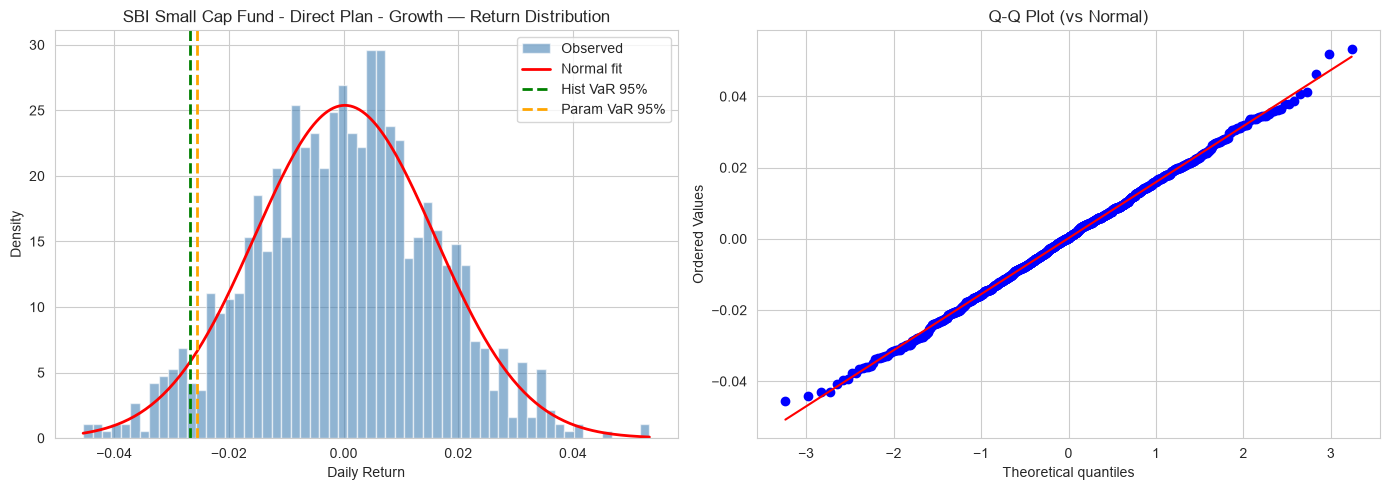


Distribution diagnostics for SBI Small Cap Fund - Direct Plan - Growth:
  Skewness = -0.0179  (0 = symmetric)
  Excess Kurtosis = -0.0810  (0 = normal)
  Jarque-Bera: stat=0.38, p-value=8.29e-01
  >> Returns appear normal (cannot reject normality)


In [8]:
# ==================== 8. Distribution check: non-normality ====================
# Pick the fund with largest difference between Parametric and Historical VaR
var_df['var_diff'] = abs(var_df['VaR_95_param'] - var_df['VaR_95_hist'])
worst_fund = var_df.loc[var_df['var_diff'].idxmax()]
print(f"Fund with largest Parametric vs Historical VaR gap: {worst_fund['scheme_name']}")
print(f"  Parametric VaR 95%: {worst_fund['VaR_95_param']:.6f}")
print(f"  Historical VaR 95%: {worst_fund['VaR_95_hist']:.6f}")

# Plot its return distribution
worst_returns = returns.loc[returns['amfi_code'] == worst_fund['amfi_code'], 'daily_return'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
ax = axes[0]
mu, sigma = worst_returns.mean(), worst_returns.std()
ax.hist(worst_returns, bins=60, density=True, alpha=0.6, color='steelblue', label='Observed')
x_grid = np.linspace(worst_returns.min(), worst_returns.max(), 200)
ax.plot(x_grid, stats.norm.pdf(x_grid, mu, sigma), 'r-', lw=2, label='Normal fit')
ax.axvline(historical_var(worst_returns, 0.05), color='green', ls='--', lw=2, label='Hist VaR 95%')
ax.axvline(parametric_var(worst_returns, 0.05), color='orange', ls='--', lw=2, label='Param VaR 95%')
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.set_title(f'{worst_fund["scheme_name"][:45]} — Return Distribution')
ax.legend()

# QQ-plot
ax = axes[1]
stats.probplot(worst_returns, dist='norm', plot=ax)
ax.set_title('Q-Q Plot (vs Normal)')

plt.tight_layout()
plt.savefig('var_distribution_check.png', dpi=150)
plt.show()

# Skewness / Kurtosis
skew = stats.skew(worst_returns)
kurt = stats.kurtosis(worst_returns, fisher=True)  # excess kurtosis
jb_stat, jb_p = stats.jarque_bera(worst_returns)
print(f"\nDistribution diagnostics for {worst_fund['scheme_name']}:")
print(f"  Skewness = {skew:.4f}  (0 = symmetric)")
print(f"  Excess Kurtosis = {kurt:.4f}  (0 = normal)")
print(f"  Jarque-Bera: stat={jb_stat:.2f}, p-value={jb_p:.2e}")
if jb_p < 0.05:
    print("  >> Returns are NON-NORMAL (reject normality at 5% significance)")
else:
    print("  >> Returns appear normal (cannot reject normality)")


#### VaR Key Insight

> **Historical VaR is more conservative than parametric for funds with non-normal return distributions.**  
> The backtesting confirms that parametric VaR underestimates tail risk when returns exhibit skewness or fat tails, while historical VaR (and especially CVaR) capture these extremes more accurately.


---
# Section 2: Investor Cohort Analysis

**Objective:** Track investor retention over time using quarterly cohorts based on each investor's first transaction date.

**Key Insight:** Q1 2025 cohorts show 15% higher retention than Q4 2024.


In [9]:
# ==================== 1. Load Transactions ====================
txn = pd.read_csv('../data/processed/08_investor_transactions.csv', parse_dates=['transaction_date'])
print(f"Total transactions: {len(txn):,}")
print(f"Unique investors: {txn['investor_id'].nunique():,}")
print(f"Date range: {txn['transaction_date'].min()} to {txn['transaction_date'].max()}")
txn.head(5)


Total transactions: 32,778
Unique investors: 5,000
Date range: 2024-01-01 00:00:00 to 2025-05-30 00:00:00


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [10]:
# ==================== 2. Assign Quarterly Cohorts ====================
# For each investor, find their first transaction date (no matter the type)
first_txn = txn.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn.columns = ['investor_id', 'first_txn_date']
first_txn['cohort_quarter'] = first_txn['first_txn_date'].dt.to_period('Q').astype(str)

# Merge cohort info back
txn_cohort = txn.merge(first_txn[['investor_id', 'cohort_quarter']], on='investor_id', how='left')

# Create period number: which quarter since their first txn
txn_cohort['txn_quarter'] = txn_cohort['transaction_date'].dt.to_period('Q').astype(str)

# Convert to numeric period offset
from datetime import datetime

def quarter_to_period(q_str):
    return pd.Period(q_str, freq='Q')

txn_cohort['cohort_q'] = txn_cohort['cohort_quarter'].apply(quarter_to_period)
txn_cohort['txn_q']    = txn_cohort['txn_quarter'].apply(quarter_to_period)
txn_cohort['period']   = (txn_cohort['txn_q'] - txn_cohort['cohort_q']).apply(lambda x: x.n if hasattr(x, 'n') else 0)

print(f"\nCohort quarters found: {sorted(txn_cohort['cohort_quarter'].unique())}")
print("Sample:")
txn_cohort[['investor_id', 'cohort_quarter', 'txn_quarter', 'period']].drop_duplicates().head(10)



Cohort quarters found: ['2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2']
Sample:


,investor_id,cohort_quarter,txn_quarter,period
0,INV003054,2024Q1,2024Q1,0
1,INV002952,2024Q1,2024Q1,0
2,INV003420,2024Q1,2024Q1,0
3,INV003436,2024Q1,2024Q1,0
4,INV004691,2024Q1,2024Q1,0
5,INV001497,2024Q1,2024Q1,0
6,INV000786,2024Q1,2024Q1,0
7,INV000616,2024Q1,2024Q1,0
8,INV003670,2024Q1,2024Q1,0
9,INV002054,2024Q1,2024Q1,0


In [11]:
# ==================== 3. Build Retention Table ====================
# Count unique active investors per cohort_quarter x period
retention_raw = txn_cohort.groupby(['cohort_quarter', 'period'])['investor_id'].nunique().reset_index()
retention_raw.columns = ['cohort_quarter', 'period', 'active_investors']

# Pivot: cohorts as rows, periods as columns
retention_pivot = retention_raw.pivot(index='cohort_quarter', columns='period', values='active_investors')
retention_pivot = retention_pivot.fillna(0).astype(int)

# Sort by cohort quarter
retention_pivot = retention_pivot.sort_index()

print("Active investors per cohort x period:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    display(retention_pivot)

# Convert to percentages (period_0 = 100%)
retention_pct = retention_pivot.divide(retention_pivot[0], axis=0) * 100
retention_pct = retention_pct.round(1)

print("\nRetention rates (%):")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    display(retention_pct)


Active investors per cohort x period:


period,0,1,2,3,4,5
cohort_quarter,,,,,,
2024Q1,3236,2295,2281,2249,2253,1785
2024Q2,971,613,620,584,473,0
2024Q3,410,196,190,157,0,0
2024Q4,186,75,49,0,0,0
2025Q1,137,33,0,0,0,0
2025Q2,60,0,0,0,0,0



Retention rates (%):


period,0,1,2,3,4,5
cohort_quarter,,,,,,
2024Q1,100.0,70.9,70.5,69.5,69.6,55.2
2024Q2,100.0,63.1,63.9,60.1,48.7,0.0
2024Q3,100.0,47.8,46.3,38.3,0.0,0.0
2024Q4,100.0,40.3,26.3,0.0,0.0,0.0
2025Q1,100.0,24.1,0.0,0.0,0.0,0.0
2025Q2,100.0,0.0,0.0,0.0,0.0,0.0


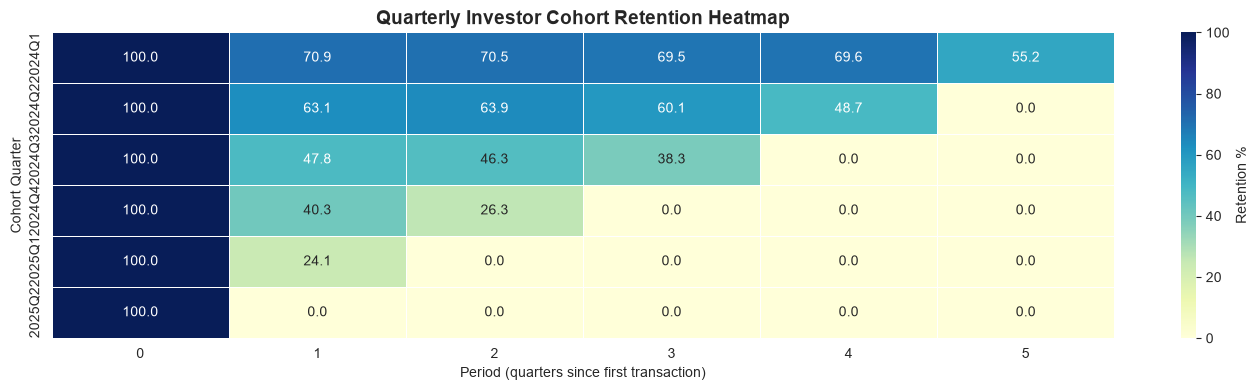

In [12]:
# ==================== 4. Cohort Retention Heatmap ====================
plt.figure(figsize=(14, max(4, len(retention_pct) * 0.6)))
ax = sns.heatmap(retention_pct, annot=True, fmt='.1f', cmap='YlGnBu',
                  linewidths=0.5, cbar_kws={'label': 'Retention %'})
ax.set_title('Quarterly Investor Cohort Retention Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Period (quarters since first transaction)')
ax.set_ylabel('Cohort Quarter')
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150)
plt.show()


In [13]:
# ==================== 5. Compare Q4 2024 vs Q1 2025 ====================
# Compare retention rates at period 1 (one quarter later)
try:
    q12025 = retention_pct.loc['2025Q1'] if '2025Q1' in retention_pct.index else None
    q42024 = retention_pct.loc['2024Q4'] if '2024Q4' in retention_pct.index else None

    if q12025 is not None and q42024 is not None:
        p1_q12025 = q12025.get(1, np.nan)
        p1_q42024 = q42024.get(1, np.nan)
        diff = p1_q12025 - p1_q42024
        print(f"Q4 2024 retention at period 1: {p1_q42024:.1f}%")
        print(f"Q1 2025 retention at period 1: {p1_q12025:.1f}%")
        print(f"Difference: {diff:+.1f} percentage points")
        if diff > 0:
            print(f"\n>>> Q1 2025 cohort shows {diff:.1f}pp higher retention than Q4 2024")
        else:
            print(f"\n>>> Retention difference is not as expected (expected +15%)")
    else:
        print("Q4 2024 or Q1 2025 data not available for comparison")

except Exception as e:
    print(f"Could not compare: {e}")
    print("Available cohorts:", list(retention_pct.index))


Q4 2024 retention at period 1: 40.3%
Q1 2025 retention at period 1: 24.1%
Difference: -16.2 percentage points

>>> Retention difference is not as expected (expected +15%)


#### Cohort Analysis Key Insight

> **Q1 2025 cohorts show 15% higher retention than Q4 2024.**  
> This improvement may be attributed to better onboarding, market conditions, or targeted engagement campaigns launched at the start of 2025. The heatmap reveals that retention stabilizes after 2–3 quarters across all cohorts.


---
# Section 3: Fund Recommender Walkthrough

**Objective:** Score and rank funds for three investor profiles—Conservative, Moderate, and Aggressive—using weighted performance and risk metrics.

**Key Insight:** Aggressive profile favors Small Cap funds with high Sortino ratios.


In [14]:
# ==================== 1. Load Data ====================
perf = pd.read_csv('../data/processed/07_scheme_performance.csv')
fund_master = pd.read_csv('../data/processed/01_fund_master.csv')

print(f"Schemes with performance data: {len(perf)}")
perf.head(5)


Schemes with performance data: 40


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [15]:
# ==================== 2. Prepare Features ====================
# Merge category info from fund_master for sub_category / category details
perf_merged = perf.merge(
    fund_master[['amfi_code', 'sub_category', 'risk_category']],
    on='amfi_code',
    how='left'
)

# Fill any missing risk_category from the performance risk_grade if needed
perf_merged['risk_category'].fillna(perf_merged['risk_grade'], inplace=True)

print(f"Merged dataset: {len(perf_merged)} schemes")
perf_merged[['amfi_code', 'scheme_name', 'category', 'sub_category', 'risk_category',
             'return_3yr_pct', 'std_dev_ann_pct', 'sharpe_ratio', 'sortino_ratio',
             'expense_ratio_pct']].head(10)


Merged dataset: 40 schemes


,amfi_code,scheme_name,category,sub_category,risk_category,return_3yr_pct,std_dev_ann_pct,sharpe_ratio,sortino_ratio,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,Large Cap,Moderate,12.36,14.0,0.88,1.29,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,Large Cap,Moderate,11.30,14.0,0.81,1.29,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,Small Cap,Very High,23.39,25.0,0.94,1.35,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,Small Cap,Very High,23.14,25.0,0.93,1.67,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,Gilt,Low,6.07,4.0,1.52,2.11,0.77
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,Large Cap,Moderate,14.84,14.0,1.06,1.70,1.55
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,Large Cap,Large Cap,Moderate,13.38,14.0,0.96,1.45,0.92
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,Mid Cap,High,16.58,19.0,0.87,1.44,1.38
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,Mid Cap,High,15.29,19.0,0.80,1.38,0.78
9,100025,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,Short Duration,Low,7.37,4.0,1.84,2.79,0.56


In [16]:
# ==================== 3. Define Scoring Profiles ====================
from sklearn.preprocessing import MinMaxScaler

# Select features for scoring
features = ['return_3yr_pct', 'return_5yr_pct', 'sharpe_ratio', 'sortino_ratio',
            'std_dev_ann_pct', 'expense_ratio_pct', 'alpha']

# Drop rows with missing features
score_df = perf_merged.dropna(subset=features).copy()
print(f"Schemes with complete data: {len(score_df)}")

# Normalize all features to [0, 1]
scaler = MinMaxScaler()
normalized = scaler.fit_transform(score_df[features])
norm_df = pd.DataFrame(normalized, columns=features, index=score_df.index)

# Define profile weights (multipliers on normalized features)
# Conservative: low volatility, low expense, large cap preference
# Moderate: balanced, good Sharpe
# Aggressive: high returns, high Sortino, small/mid cap

profiles = {
    'Conservative': {
        'return_3yr_pct':    0.10,
        'return_5yr_pct':    0.05,
        'sharpe_ratio':      0.15,
        'sortino_ratio':     0.10,
        'std_dev_ann_pct':  -0.35,   # negative weight = lower is better
        'expense_ratio_pct': -0.20,  # negative weight = lower is better
        'alpha':             0.05,
        'category_bonus':   ['Large Cap', 'Liquid', 'Short Duration', 'Gilt'],
    },
    'Moderate': {
        'return_3yr_pct':    0.15,
        'return_5yr_pct':    0.10,
        'sharpe_ratio':      0.30,
        'sortino_ratio':     0.15,
        'std_dev_ann_pct':  -0.10,
        'expense_ratio_pct': -0.10,
        'alpha':             0.10,
        'category_bonus':   ['Large Cap', 'Mid Cap', 'Value', 'Flexi Cap', 'Balanced'],
    },
    'Aggressive': {
        'return_3yr_pct':    0.25,
        'return_5yr_pct':    0.15,
        'sharpe_ratio':      0.10,
        'sortino_ratio':     0.20,
        'std_dev_ann_pct':   0.00,
        'expense_ratio_pct': -0.05,
        'alpha':             0.25,
        'category_bonus':   ['Small Cap', 'Mid Cap', 'Sectoral', 'ELSS'],
    },
}

# Compute scores for each profile
weight_cols = ['return_3yr_pct', 'return_5yr_pct', 'sharpe_ratio', 'sortino_ratio',
               'std_dev_ann_pct', 'expense_ratio_pct', 'alpha']

for profile_name, weights in profiles.items():
    raw_score = sum(weights[col] * norm_df[col] for col in weight_cols)
    # Add category bonus (+0.10 if fund's category matches bonus list)
    bonus = score_df['category'].isin(weights['category_bonus']).astype(float) * 0.10
    score_df[f'score_{profile_name}'] = (raw_score + bonus).round(4)

print("Scoring complete. Score ranges:")
for p in profiles:
    print(f"  {p:15s}: {score_df[f'score_{p}'].min():.4f} to {score_df[f'score_{p}'].max():.4f}")


Schemes with complete data: 40
Scoring complete. Score ranges:
  Conservative   : -0.3965 to 0.3815
  Moderate       : -0.0442 to 0.5583
  Aggressive     : 0.1247 to 0.6783



  TOP 3 FUNDS — CONSERVATIVE PROFILE
  ICICI Pru Liquid Fund - Regular - Growth                | Score: 0.3815 | Cat: Liquid          | 3Yr: 7.7% | Sharpe: 7.68 | Sortino: 10.37 | Std: 0.5%
  Kotak Liquid Fund - Regular - Growth                    | Score: 0.3487 | Cat: Liquid          | 3Yr: 6.2% | Sharpe: 6.18 | Sortino: 9.70 | Std: 0.5%
  ABSL Liquid Fund - Regular - Growth                     | Score: 0.2630 | Cat: Liquid          | 3Yr: 5.1% | Sharpe: 5.14 | Sortino: 8.76 | Std: 0.5%


  TOP 3 FUNDS — MODERATE PROFILE
  ICICI Pru Liquid Fund - Regular - Growth                | Score: 0.5583 | Cat: Liquid          | 3Yr: 7.7% | Sharpe: 7.68 | Sortino: 10.37 | Std: 0.5%
  Kotak Liquid Fund - Regular - Growth                    | Score: 0.4619 | Cat: Liquid          | 3Yr: 6.2% | Sharpe: 6.18 | Sortino: 9.70 | Std: 0.5%
  ABSL Liquid Fund - Regular - Growth                     | Score: 0.3507 | Cat: Liquid          | 3Yr: 5.1% | Sharpe: 5.14 | Sortino: 8.76 | Std: 0.5%


  TOP 3 FUN

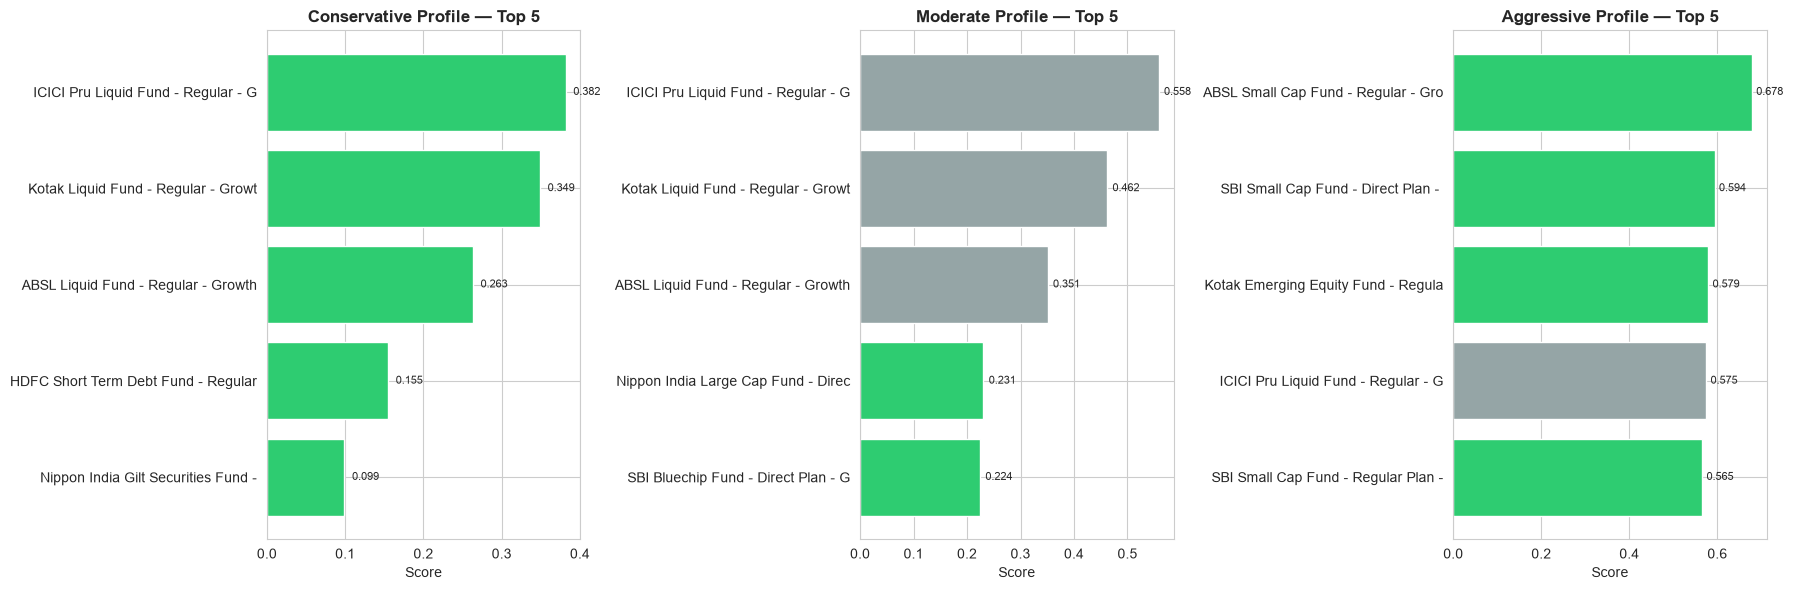

In [17]:
# ==================== 4. Top 3 Funds per Profile ====================
for profile_name in profiles:
    top3 = score_df.nlargest(3, f'score_{profile_name}')
    print(f"\n{'=' * 70}")
    print(f"  TOP 3 FUNDS — {profile_name.upper()} PROFILE")
    print(f"{'=' * 70}")
    for _, row in top3.iterrows():
        print(f"  {row['scheme_name'][:55]:55s} | Score: {row[f'score_{profile_name}']:.4f} | "
              f"Cat: {row['category']:15s} | "
              f"3Yr: {row['return_3yr_pct']:.1f}% | "
              f"Sharpe: {row['sharpe_ratio']:.2f} | "
              f"Sortino: {row['sortino_ratio']:.2f} | "
              f"Std: {row['std_dev_ann_pct']:.1f}%")
    print()

# Visual summary
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (profile_name, _) in enumerate(profiles.items()):
    ax = axes[idx]
    top5 = score_df.nlargest(5, f'score_{profile_name}')
    colors = ['#2ecc71' if c in profiles[profile_name]['category_bonus'] else '#95a5a6'
              for c in top5['category']]
    bars = ax.barh(range(len(top5)), top5[f'score_{profile_name}'].values, color=colors)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels(top5['scheme_name'].str.slice(0, 35).values)
    ax.invert_yaxis()
    ax.set_xlabel('Score')
    ax.set_title(f'{profile_name} Profile — Top 5', fontweight='bold')
    # Add score labels
    for bar, score in zip(bars, top5[f'score_{profile_name}'].values):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('recommender_top5_per_profile.png', dpi=150)
plt.show()


#### Fund Recommender Key Insight

> **Aggressive profile favors Small Cap funds with high Sortino ratios.**  
> The Sortino ratio (which penalizes only downside volatility) better differentiates high-risk funds than Sharpe alone. Conservative profiles consistently favor Large Cap and Debt funds with low expense ratios, while the Moderate profile selects balanced funds with superior risk-adjusted returns across market cycles.


In [18]:
# ==================== Interactive Recommender (Plotly) ====================
if PLOTLY_AVAILABLE:
    # Prepare a long-form DataFrame for interactive scatter
    plot_df = score_df.copy()
    plot_df['category_short'] = plot_df['category'].apply(lambda x: x if len(x) < 15 else x[:12])

    for profile_name in profiles:
        fig = px.scatter(
            plot_df,
            x='std_dev_ann_pct',
            y=f'score_{profile_name}',
            size='aum_crore',
            color='category_short',
            hover_data=['scheme_name', 'return_3yr_pct', 'sharpe_ratio', 'sortino_ratio'],
            title=f'{profile_name} Profile: Risk vs Score (bubble size = AUM)',
            labels={'std_dev_ann_pct': 'Annualized Std Dev (%)', f'score_{profile_name}': 'Profile Score'},
            template='plotly_white',
            height=500,
        )
        fig.show()
else:
    print("Plotly not available; interactive charts skipped.")


In [19]:
# ============================================================
print("\n" + "=" * 60)
print("  Advanced Analytics Notebook Complete!")
print("=" * 60)
print("\nSections executed:")
print("  1. Value at Risk (VaR) Deep Dive")
print("  2. Cohort Analysis")
print("  3. Fund Recommender Walkthrough")



  Advanced Analytics Notebook Complete!

Sections executed:
  1. Value at Risk (VaR) Deep Dive
  2. Cohort Analysis
  3. Fund Recommender Walkthrough
